## Background

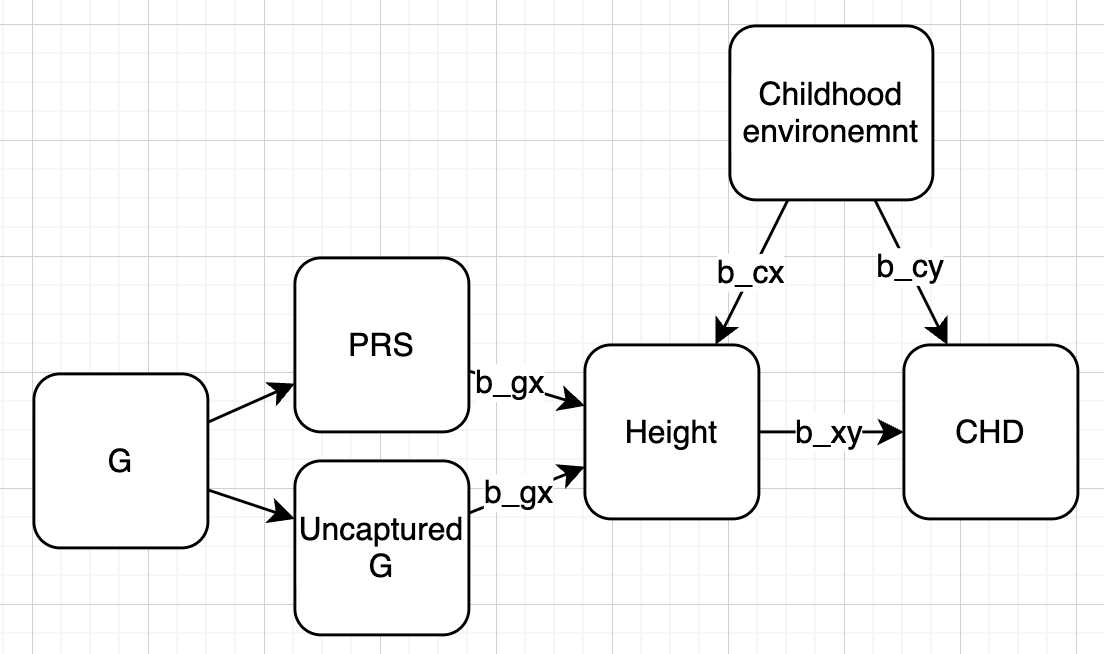

$$
X = \beta_{gx} G + \beta_{cx} C + \epsilon_x
$$

$$
Y = \beta_{xy} X + \beta_{cy} C + \epsilon_y
$$

Two stage least squares aims to estimate the causal effect of X on Y, $\beta_{xy}$, by using G as an instrument for X. The first stage regression is:

$$
X = \beta_{gx} G
$$

Make a prediction of X from G, and then use this predicted value of X in the second stage regression to estimate $\beta_{xy}$.  

$$
\hat{X} = \hat{\beta}_{gx} G
$$

And then the second stage regression is:

$$
Y = \beta_{xy} \hat{X} + error
$$

So $\hat{\beta_{xy}}$ is the estimate of the causal effect of X on Y, which is independent of the common confounding of X and Y.

Can we estimate the effect of environment on Y using the residual height?

According to the model described above, the influence of adverse childhood environment on CHD is due to two paths:

- $\beta_{cy}$: the direct effect of environment on CHD
- $\beta_{cx} \beta_{xy}$: the effect of environment on CHD mediated by height

The PRS effect estimate on CHD represents $\beta_{xy}$, the causal effect of height on CHD. Can we express $\beta_{cy}$ in terms of values that are observable in the data?

$$
\begin{aligned}
cov(X, Y) &= cov(\beta_{gx} G + \beta_{cx} C + \epsilon_x, \beta_{xy} X + \beta_{cy} C + \epsilon_y) \\
&= \beta_{gx} \beta_{xy} var(G) + (\beta_{cx} \beta_{xy} + \beta_{cy}) var(C) + \beta_{xy} var(\epsilon_x) \\
&= \beta_{xy} var(X) h^2 + (\beta_{cx}^2 \beta_{xy} + \beta_{cx} \beta_{cy}) var(C) + \beta_{xy} var(X)((1-h^2) - var(C)) \\
\end{aligned}
$$

This can be rearranged to be find an expression for $\beta_{cy}$:

$$
\begin{aligned}
\beta_{cy} &= \frac{cov(X, Y) - \beta_{xy} var(X) h^2 - [(1-h^2) var(X) - \beta_{cx}^2 var(C)] \beta_{xy} - \beta_{cx}^2 \beta_{xy} var(C)}{var(C) \beta_{cx}} \\
&= \frac{cov(X, Y) - \beta_{xy} var(X)}{var(C) \beta_{cx}}
\end{aligned}
$$

In principle we can also express $\beta_{cy}$ in terms of the covariance of residual height association with CHD, which is observable in the data:

$$
\beta_{cy} = \frac{cov(X, Y | \hat{G}) - \beta_{xy} (var(X)(1-h^2) + h^2 var(X)(1-R^2))}{var(C) \beta_{cx}}
$$

where $R^2$ is the proportion of the heritability of height explained by the PRS.

So we should be able to check empirically that 

$$
cov(X, Y | \hat{G}) - \beta_{xy} (var(X)(1-h^2) + h^2 var(X)(1-R^2)) = cov(X, Y) = \beta_{xy} var(X)
$$

In order to estimate $\beta_{cy}$, we need to know two parameters:

- $var(C)$: the variance of 'childhood environment'. It is essentially $var(C) = (1 - h^2) var(X) - var(\epsilon_x)$, where $var(\epsilon_x)$ is the developmental stochastic process, leaving $var(C)$ to represent the shared and non-shared environment. Empirically, this is estimated at around 10% of the variance in height, so we can set $var(C) = 0.1 var(X)$.
- $\beta_{cx}$: the effect of childhood environment on height. This cannot be easily estimated, so we can set this to 1, which means that when we interpret $\beta_{cy}$, we are interpreting it as the effect of childhood environment on CHD relative to its effect on height.


This simulation checks that the expected terms described above are recapitulated in simulated data.

In [1]:
library(dplyr)
sim <- function(b_xy, b_uy, b_ux=1, b_prs=1, h2=0.7, r2_env_height=0.1, var_u = 1, var_x=1, var_ey = 1, r2_prs=1, n = 100000) {
    r2_xe <- 1 - h2 - r2_env_height
    var_prs <- h2 * var_x / b_prs^2
    var_u <- r2_env_height * var_x / b_ux^2
    var_ex <- r2_xe * var_x

    args <- list(
        h2 = h2,
        r2_prs = r2_prs,
        b_xy = b_xy,
        b_uy = b_uy,
        b_ux = b_ux,
        b_prs = b_prs,
        v_ex = var_ex,
        v_ey = var_ey,
        v_u = var_u,
        v_prs = var_prs,
        n = n
    )
    dat <- tibble(
        prs_explained = rnorm(n, mean = 0, sd = sqrt(args$v_prs * b_prs * r2_prs)),
        prs_unexplained = rnorm(n, mean = 0, sd = sqrt(args$v_prs * b_prs * (1 - r2_prs))),
        prs = prs_explained + prs_unexplained,
        u = rnorm(n, mean = 0, sd = sqrt(args$v_u)),
        ex = rnorm(n, mean = 0, sd = sqrt(args$v_ex)),
        x = prs + u * b_ux + ex,
        residual_x = x - prs_explained,
        ey = rnorm(n, mean = 0, sd = sqrt(args$v_ey)),
        y = b_xy * x + b_uy * u + ey
    )
    return(list(args, dat))
}

est_obs <- function(simdat) {
    dat <- simdat[[2]]
    xhat <- fitted.values(lm(x ~ prs_explained, dat))
    residual <- residuals(lm(x ~ prs_explained, dat))
    h2 <- simdat[[1]]$h2
    r2_prs <- simdat[[1]]$r2_prs
    tibble(
        var_x = var(dat$x),
        var_prs_explained = var(dat$prs_explained),
        var_prs_unexplained = var(dat$prs_unexplained),
        var_prs = var(dat$prs_explained + dat$prs_unexplained),
        var_residual = var(dat$residual_x),
        var_y = var(dat$y),
        var_u = var(dat$u),
        var_xhat = var(xhat),
        var_ex = var(dat$ex),

        cov_prs_y = cov(dat$prs_explained, dat$y),
        cov_prs_x = cov(dat$prs_explained, dat$x),
        cov_xhat_y = cov(xhat, dat$y),
        cov_residual_y = cov(residual, dat$y),
        cov_x_y = cov(dat$x, dat$y),

        lm_x_y = lm(y ~ x, dat)$coef[2],
        lm_xhat_y = lm(dat$y ~ xhat)$coef[2],
        lm_residual_y = lm(dat$y ~ residual)$coef[2],
        lm_u_y = simdat[[1]]$b_uy,
        lm_u_y_resx = simdat[[1]]$b_uy,
        est_u_y = (cov_x_y - cov_prs_y) / (var_x - var_prs),
        numerator = (cov_x_y - lm_xhat_y * var_x),
        denominator = (cov_residual_y - lm_xhat_y * (var_x * (1 - h2) + h2 * var_x * (1 - r2_prs))),
        ratio = numerator / denominator
    ) %>% bind_cols(simdat[[1]]) %>% as.list()
}

est_exp <- function(res_obs) {

    a <- res_obs %>% as_tibble() %>% mutate(
        exp_var_x = var_prs * b_prs^2 + var_u * b_ux^2 + v_ex,
        exp_var_residual = exp_var_x - var_prs * b_prs^2 + var_prs * b_prs^2 * (1-r2_prs),
        exp_var_prs = h2 * exp_var_x,
        exp_var_prs_explained = h2 * r2_prs * exp_var_x,
        exp_var_prs_unexplained = h2 * (1 - r2_prs) * exp_var_x,
        exp_var_residual = exp_var_x - exp_var_prs_explained,
        exp_var_ex = exp_var_x * (1 - h2) - var_u * b_ux^2,
        # exp_var_y = b_xy^2 * exp_var_prs + (b_ux * b_xy + b_uy)^2 * var_u + v_ey + b_xy^2 * exp_var_ex,
        exp_var_y = b_xy^2 * h2 * exp_var_x + (b_ux * b_xy + b_uy)^2 * var_u + v_ey + b_xy^2 * (exp_var_x * (1-h2) - v_u * b_ux^2),

        # exp_cov_x_y = var_prs * b_prs^2 * b_xy + var_u * (b_ux^2 * b_xy + b_ux * b_uy) + v_ex * b_xy,
        exp_cov_x_y = b_xy * h2 * exp_var_x + (b_ux^2 * b_xy + b_uy * b_ux) * v_u + v_ex * b_xy,
        exp_cov_x_y = b_xy * h2 * exp_var_x + (b_ux^2 * b_xy + b_uy * b_ux) * v_u + (exp_var_x * (1-h2) - v_u * b_ux^2) * b_xy,
        exp_cov_prs_y = exp_var_prs_explained * b_prs * b_xy,
        exp_cov_prs_x = exp_var_prs_explained * b_prs,
        # exp_cov_residual_y = var_u * (b_ux^2 * b_xy + b_ux * b_uy) + v_ex * b_xy + (var_prs * b_prs * b_xy) * (1-r2_prs),
        exp_cov_residual_y = var_u * (b_ux^2 * b_xy + b_ux * b_uy) + (exp_var_x * (1-h2) - v_u * b_ux^2) * b_xy + (h2 * exp_var_x * b_prs * b_xy) * (1-r2_prs),

        exp_lm_x_y = exp_cov_x_y / exp_var_x,        
        exp_lm_residual_y = exp_cov_residual_y / exp_var_residual,
        exp_lm_xhat_y = exp_cov_prs_y / exp_cov_prs_x,
        # exp_lm_u_y = (exp_cov_x_y - (b_xy * h2 * exp_var_x) - (exp_var_x * (1 - h2) - v_u * b_ux^2) * b_xy - (b_ux^2 * b_xy) * v_u) / (b_ux * v_u)
        exp_lm_u_y = (exp_cov_x_y - (b_xy * exp_var_x)) / (b_ux * v_u),
        exp_lm_u_y_resx = (exp_cov_residual_y - b_xy * (exp_var_x * (1 - h2) + h2 * exp_var_x * b_prs * (1 - r2_prs))) / (v_u * b_ux),
        exp_ratio = exp_lm_u_y / exp_lm_u_y_resx
    )
    b <- a %>% select(starts_with("exp"))
    names(b) <- gsub("exp_", "", names(b))
    b <- tibble(parameter = names(b), exp = as.numeric(b[1, ]))

    a <- a %>% select(-starts_with("exp"))
    a <- tibble(parameter = names(a), obs = as.numeric(a[1, ]))

    inner_join(a, b, by = "parameter") %>% mutate(ratio = round(obs / exp, 2)) %>% as.data.frame
}

res <- sim(-0.5, -0.2, 1, r2_prs = 0.7, h2=0.7, n=1000000) %>% est_obs %>% est_exp
res


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




parameter,obs,exp,ratio
<chr>,<dbl>,<dbl>,<dbl>
var_x,0.9998816,0.9993922,1.00
var_prs_explained,0.4891528,0.4897022,1.00
var_prs_unexplained,0.2099084,0.2098724,1.00
var_prs,0.6990508,0.6995745,1.00
var_residual,0.5116245,0.5096900,1.00
var_y,1.2706040,1.2740153,1.00
var_ex,0.1999562,0.1994763,1.00
cov_prs_y,-0.2434720,-0.2448511,0.99
cov_prs_x,0.4887049,0.4897022,1.00


Now to put this to use, the main objective is to estimate $\beta_{cy}$. However it is clear that we cannot estimate the three missing values $\beta_{cx}$, $\beta_{cy}$ and $var(c)$ as the model is underspecified. However we can fix $\beta_{cx} = 1$ so that we are estimating $\beta_{cy}$ in terms of the effect of C on Y relative to its effect on X (height). We can also use the literature to fix the variances of G=0.7, C=0.15 and E=0.15.

We will have the following variables in our analysis:

- Height
- PRS
- Outcome variable

We will be able to estimate a relative effect of the childhood environment C on the outcome as 

$$
\beta_{cy*} = \beta_{cy}\beta_{cx} = \frac{cov(X, Y) - \beta_{xy} var(X)}{var(C)}
$$

Or

$$
\beta_{cy*} = \beta_{cy}\beta_{cx} = \frac{cov(X, Y | \hat{G}) - \beta_{xy} (var(X)(1-h^2) + h^2 var(X)(1-R^2))}{var(C)}
$$

Where:
- $\beta_{xy}$ is estimated using `AER::ivreg` for proper instrumental variable regression
- $var(C)$ is set to 0.15 based on literature
- $h^2 = 0.7$ is the heritability of height
- $R^2$ is the proportion of heritability explained by the PRS

Both methods should give the same estimate in theory. We use bootstrapping to obtain standard errors, with parametric resampling of $\beta_{xy}$ from its 2SLS sampling distribution for computational efficiency.

Because we have two estimates of $\beta_{cy}$ we can combine them using generalised least squares estimation as long as we can estimate the covariance between the two estimates.

The estimates are:

- $\hat{\beta}_{cy,1} = \hat{\theta}_1$ - using height
- $\hat{\beta}_{cy,2} = \hat{\theta}_2$ - using residual height

$$
cov(\theta_1, \theta_2) \approx \frac{var(Y) cov(X,X_{res}) + cov(X, Y)cov(X_{res},Y)}{N(\sigma_C^2)^2}
$$

We can use this to make the covariance matrix 

$$
\Omega = \left (

 \begin{matrix}
 var(\hat{\theta}_1)& cov(\hat{\theta}_1,\hat{\theta}_2) \\
 cov(\hat{\theta}_1,\hat{\theta}_2) & var(\hat{\theta}_2) \\
\end{matrix}
\right )
$$

Which can then be plugged into the GLS estimator, where $\mathbf{\hat{B}} = [\hat{\theta}_1, \hat{\theta}_2]^T$ and $\mathbf{w} = [1,1]^T$

$$
\mathbf{W} = \frac{\Omega^{-1} \mathbf{w}}{\mathbf{w}^T \Omega^{-1}\mathbf{w}}
$$

and

$$
\hat{\beta}_{cy} = \mathbf{W}^T \mathbf{\hat{B}}
$$

with 

$$
var(\hat{\beta}_{cy}) = \frac{1}{\mathbf{w}^T \Omega^{-1}\mathbf{w}}
$$

In [2]:
# Function to estimate beta_cy from height, PRS, and outcome

estimate_beta_cy <- function(height, prs, outcome, var_c = 0.15, h2 = 0.7, n_boot = 1000) {
    
    # Detect if outcome is binary or continuous
    unique_vals <- unique(outcome)
    is_binary <- length(unique_vals) == 2 && all(sort(unique_vals) == c(0, 1))
    
    # Store original outcome for prevalence calculation
    outcome_original <- outcome
    
    # Calculate prevalence if binary
    if (is_binary) {
        prevalence <- mean(outcome)
        # Calculate liability scale threshold transformation factor
        threshold <- qnorm(prevalence)
        liability_scale_factor <- dnorm(threshold)
        cat(sprintf("Binary outcome detected (prevalence = %.3f)\n", prevalence))
        cat(sprintf("Liability scale transformation factor = %.4f\n", liability_scale_factor))
    } else {
        # Standardize continuous outcome
        outcome <- (outcome - mean(outcome)) / sd(outcome)
        cat("Continuous outcome detected - standardized to mean=0, SD=1\n")
        prevalence <- NA
        liability_scale_factor <- 1
    }
    
    # Use instrumental variable regression to estimate causal effect
    library(AER)
    dat_iv <- data.frame(height = height, prs = prs, outcome = outcome)
    iv_model <- ivreg(outcome ~ height | prs, data = dat_iv)
    
    # Extract beta_xy and its standard error (on observed scale)
    beta_xy_prs_observed <- coef(iv_model)[2]
    se_beta_xy_observed <- summary(iv_model)$coefficients[2, 2]
    
    # Transform to liability scale if binary
    beta_xy_prs <- beta_xy_prs_observed / liability_scale_factor
    se_beta_xy <- se_beta_xy_observed / liability_scale_factor
    
    # Calculate R^2 for PRS
    model_prs <- lm(height ~ prs)
    prs_explained <- fitted.values(model_prs)
    r2_prs <- var(prs_explained) / var(height)
    
    # Estimate beta_cy using method 1 (from covariance of height and outcome)
    beta_cy_method1_observed <- (cov(height, outcome) - beta_xy_prs_observed * var(height)) / var_c
    
    # Method 2: Using height residual
    # Get residual height (height not explained by PRS)
    residual_height <- residuals(model_prs)
    
    # Estimate beta_cy using method 2 (from residual height)
    beta_cy_method2_observed <- (cov(residual_height, outcome) - beta_xy_prs_observed * var(residual_height)) / var_c
    
    # Transform to liability scale if binary
    beta_cy_method1 <- beta_cy_method1_observed / liability_scale_factor
    beta_cy_method2 <- beta_cy_method2_observed / liability_scale_factor
    
    # Parametric bootstrap using 2SLS SE for beta_xy
    n <- length(height)
    boot_results <- matrix(NA, n_boot, 2)
    
    for(i in 1:n_boot) {
        # Sample with replacement
        idx <- sample(1:n, n, replace = TRUE)
        h_boot <- height[idx]
        p_boot <- prs[idx]
        y_boot <- outcome[idx]
        
        # Parametrically resample beta_xy from its sampling distribution
        beta_xy_boot_observed <- rnorm(1, mean = beta_xy_prs_observed, sd = se_beta_xy_observed)
        beta_xy_boot <- beta_xy_boot_observed / liability_scale_factor
        
        # Method 1 bootstrap
        boot_observed_1 <- (cov(h_boot, y_boot) - beta_xy_boot_observed * var(h_boot)) / var_c
        boot_results[i, 1] <- boot_observed_1 / liability_scale_factor
        
        # Method 2 bootstrap
        model_prs_boot <- lm(h_boot ~ p_boot)
        res_boot <- residuals(model_prs_boot)
        boot_observed_2 <- (cov(res_boot, y_boot) - beta_xy_boot_observed * var(res_boot)) / var_c
        boot_results[i, 2] <- boot_observed_2 / liability_scale_factor
    }
    
    # Calculate standard errors
    se_method1 <- sd(boot_results[, 1])
    se_method2 <- sd(boot_results[, 2])
    
    # Calculate covariance between the two estimators using GLS
    # cov(β̂_cy,1, β̂_cy,2) ≈ 1/(N·(σ_C²)²) * [var(Y)var(X,X_res) + var(X,Y)var(X_res,Y)]
    cov_x_xres <- cov(height, residual_height)
    cov_x_y <- cov(height, outcome)
    cov_xres_y <- cov(residual_height, outcome)
    var_y <- var(outcome)
    
    # Covariance of the two beta_cy estimates
    cov_estimators <- (1 / (n * var_c^2)) * (var_y * cov_x_xres + cov_x_y * cov_xres_y)
    
    # Build variance-covariance matrix
    var_method1 <- se_method1^2
    var_method2 <- se_method2^2
    Sigma <- matrix(c(var_method1, cov_estimators,
                      cov_estimators, var_method2), nrow = 2)
    
    # GLS weights (inverse of variance-covariance matrix)
    Sigma_inv <- solve(Sigma)
    weights <- Sigma_inv %*% c(1, 1)
    weight_sum <- sum(weights)
    
    # GLS combined estimate
    beta_cy_combined <- (weights[1] * beta_cy_method1 + weights[2] * beta_cy_method2) / weight_sum
    
    # Variance of combined estimate: var(β̂_combined) = 1 / (1' Σ^(-1) 1)
    var_combined <- as.numeric(1 / (t(c(1, 1)) %*% Sigma_inv %*% c(1, 1)))
    se_combined <- sqrt(var_combined)
    
    # Apply GLS weights to bootstrap distributions
    boot_combined <- (weights[1] * boot_results[, 1] + weights[2] * boot_results[, 2]) / weight_sum
    
    # Return results
    return(list(
        beta_xy = beta_xy_prs,
        se_beta_xy = se_beta_xy,
        beta_cy_method1 = beta_cy_method1,
        beta_cy_method2 = beta_cy_method2,
        beta_cy_combined = beta_cy_combined,
        se_method1 = se_method1,
        se_method2 = se_method2,
        se_combined = se_combined,
        cov_estimators = cov_estimators,
        correlation_estimators = cov_estimators / (se_method1 * se_method2),
        weight_method1 = weights[1] / weight_sum,
        weight_method2 = weights[2] / weight_sum,
        r2_prs = r2_prs,
        is_binary = is_binary,
        prevalence = if(is_binary) prevalence else NA,
        outcome_scale = if(is_binary) "liability" else "standardized",
        beta_cy_method1_observed = beta_cy_method1_observed,
        beta_cy_method2_observed = beta_cy_method2_observed,
        boot_distribution_method1 = boot_results[, 1],
        boot_distribution_method2 = boot_results[, 2],
        boot_distribution_combined = boot_combined
    ))
}


In [3]:
# Generate simulated data
simdat <- sim(b_xy = -0.5, b_uy = -0.2, b_ux = 1, b_prs=1, h2=0.7, 
                r2_env_height=0.15, r2_prs=0.4, n=100000)
dat <- simdat[[2]]

# Run estimation
results <- estimate_beta_cy(
    height = dat$x,
    prs = dat$prs_explained,
    outcome = dat$y,
    var_c = 0.15,
    h2 = 0.7,
    n_boot = 500
)
str(results)


Continuous outcome detected - standardized to mean=0, SD=1


Loading required package: car

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Loading required package: lmtest

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: survival



List of 21
 $ beta_xy                   : Named num -0.442
  ..- attr(*, "names")= chr "height"
 $ se_beta_xy                : num 0.00527
 $ beta_cy_method1           : Named num -0.174
  ..- attr(*, "names")= chr "height"
 $ beta_cy_method2           : Named num -0.174
  ..- attr(*, "names")= chr "height"
 $ beta_cy_combined          : Named num -0.174
  ..- attr(*, "names")= chr "height"
 $ se_method1                : num 0.0407
 $ se_method2                : num 0.0304
 $ se_combined               : num 0.0277
 $ cov_estimators            : num 0.000392
 $ correlation_estimators    : num 0.317
 $ weight_method1            : num 0.297
 $ weight_method2            : num 0.703
 $ r2_prs                    : num 0.281
 $ is_binary                 : logi FALSE
 $ prevalence                : logi NA
 $ outcome_scale             : chr "standardized"
 $ beta_cy_method1_observed  : Named num -0.174
  ..- attr(*, "names")= chr "height"
 $ beta_cy_method2_observed  : Named num -0.174
  ..- at

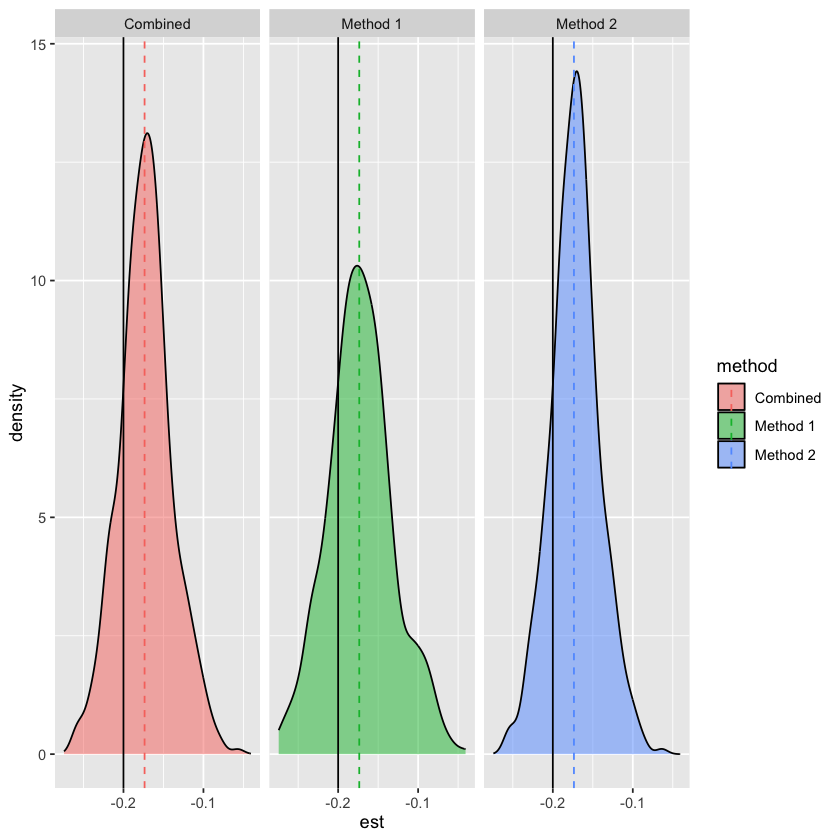

In [5]:
library(ggplot2)

# Plot bootstrap distributions
boot_df <- tibble(
    est = c(results$boot_distribution_method1, results$boot_distribution_method2, results$boot_distribution_combined),
    method = c(rep("Method 1", 500),
               rep("Method 2", 500),
               rep("Combined", 500))
)
est_df <- tibble(
    method = c("Method 1", "Method 2", "Combined"),
    estimate = c(results$beta_cy_method1, results$beta_cy_method2, results$beta_cy_combined),
    se = c(results$se_method1, results$se_method2, results$se_combined)
)
ggplot(boot_df, aes(x = est, fill = method)) +
    geom_density(alpha = 0.5) +
    geom_vline(data = est_df, aes(xintercept = estimate, color = method), linetype = "dashed") +
    geom_vline(xintercept = -0.2) +
    facet_grid(. ~ method)




In [6]:
library(furrr)
library(dplyr)

scenarios <- expand.grid(
    b_xy = c(-0.3, 0),
    b_cy = c(-0.1, -0.2),
    b_cx = c(1, 0.5),
    r2_prs = c(0.2, 0.4, 0.7),
    n = c(100000)
) %>% mutate(scenario_id = row_number())

fn <- function(b_xy, b_cy, b_cx, r2_prs, n, scenario_id) {
    set.seed(123 + scenario_id)

    # Generate simulated data
    simdat <- sim(
        b_xy = b_xy,
        b_uy = b_cy,
        b_ux = b_cx,
        b_prs = 1,
        h2 = 0.7,
        r2_env_height = 0.15,
        r2_prs = r2_prs,
        n = n
    )
    dat <- simdat[[2]]
    
    # Run estimation (fewer bootstrap iterations for speed)
    res <- estimate_beta_cy(
        height = dat$x,
        prs = dat$prs_explained,
        outcome = dat$y,
        var_c = 0.15,
        h2 = 0.7,
        n_boot = 50
    )
    bind_cols(
        tibble(b_xy=b_xy, b_cy=b_cy, b_cx=b_cx, r2_prs=r2_prs, n=n, scenario_id=scenario_id),
        tibble(beta_xy = res$beta_xy,
               se_beta_xy = res$se_beta_xy,
               beta_cy_method1 = res$beta_cy_method1,
               beta_cy_method2 = res$beta_cy_method2,
               beta_cy = res$beta_cy_combined,
               se_method1 = res$se_method1,
               se_method2 = res$se_method2,
               se_beta_cy = res$se_combined,)
    )
}
fn(0, -0.1, 1, 0.4, 100000, 1)

Loading required package: future




Attaching package: ‘future’


The following object is masked from ‘package:survival’:

    cluster


The following object is masked from ‘package:lmtest’:

    reset




Continuous outcome detected - standardized to mean=0, SD=1


b_xy,b_cy,b_cx,r2_prs,n,scenario_id,beta_xy,se_beta_xy,beta_cy_method1,beta_cy_method2,beta_cy,se_method1,se_method2,se_beta_cy
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,-0.1,1,0.4,1e+05,1,-0.003371626,0.005970865,-0.08534579,-0.08534579,-0.08534579,0.04943282,0.03357934,0.0300717


In [7]:
res <- lapply(1:nrow(scenarios), function(i) {
    fn(scenarios[i,]$b_xy, scenarios[i,]$b_cy, scenarios[i,]$b_cx, scenarios[i,]$r2_prs, scenarios[i,]$n, scenarios[i,]$scenario_id)
}) %>% bind_rows()
# fn(scenarios[1,]$b_xy, scenarios[1,]$b_cy, scenarios[1,]$b_cx, scenarios[1,]$r2_prs, scenarios[1,]$n, scenarios[1,]$scenario_id)

# plan(multicore, workers=8)
# future_pmap(scenarios[1,], fn) %>% bind_rows()

Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD=1
Continuous outcome detected - standardized to mean=0, SD

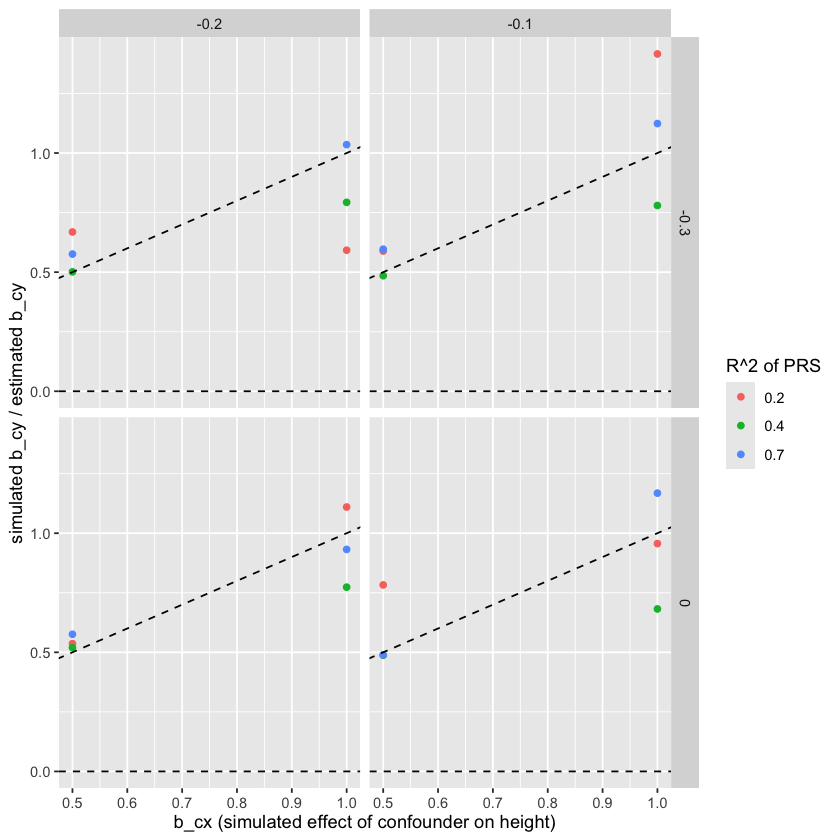

In [8]:
res %>% ggplot(aes(x = b_cx, y = b_cy / beta_cy, color = factor(r2_prs))) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
    facet_grid(b_xy ~ b_cy) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(x = "b_cx (simulated effect of confounder on height)", y = "simulated b_cy / estimated b_cy", color = "R^2 of PRS")

## Summary

- The `estimate_beta_cy` function can be used to estimate the influence of childhood environment on health outcomes.
- This is estimated twice, once using height and once using residual height. Consistency of the effect estimates indicates gene-environment equivalence.
- Meta-analysis of the two estimates can be performed using generalised least squares to give an overall estimate with tighter confidence intervals
- In broader context: We demonstrate that the height, residual height and height PRS exhibit different effects on health outcomes. This is consistent with residual height being enriched for the influence of childhood environment on the outcomes. This method aims to estimate that childhood environment -> outcome association.

## Problems

- The estimate using PRS and residual give identical betas, which suggests that I am wrong about being able to meta-analyse them if there is no sampling variation between them
- When the outcome of interest is binary what is the appropriate way to estimate $\beta_{cy}$? Note that the scale of this estimate needs to be interpreted as "the effect of childhood on Y relative to its effect on X". So when X is continuous and Y is binary then we need to think about what the scales of X and Y should be such that if $\hat{\beta}_{cy} = 1$ then we interpret the influence of childhood on Y to be equal to its effect on X.